In [ ]:
!git clone https://github.com/Savit10/cuda.git
%cd cuda

In [ ]:
!nvidia-smi

In [ ]:
!ls

In [ ]:
# Initialize timing log file
LOG_FILE = "timing_log.txt"

def log_timing(label, output, has_kernel=False):
    """Log timing output to file with kernel indicator"""
    kernel_tag = "[GPU KERNEL]" if has_kernel else "[CPU ONLY]"
    with open(LOG_FILE, "a") as f:
        f.write(f"\n{'='*60}\n")
        f.write(f"{kernel_tag} {label}\n")
        f.write(f"{'='*60}\n")
        f.write(output + "\n")

# Clear log file at start of session
with open(LOG_FILE, "w") as f:
    f.write("CUDA Learning - Timing Log\n")
    f.write(f"Generated: {__import__('datetime').datetime.now()}\n")
    
print(f"Timing log initialized: {LOG_FILE}")

In [ ]:
%%writefile hello.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <vector>

#define CHECK(call)                                   \
do {                                                  \
    cudaError_t err = call;                           \
    if (err != cudaSuccess) {                         \
        printf("CUDA error %s:%d: %s\n",              \
               __FILE__, __LINE__,                    \
               cudaGetErrorString(err));              \
        exit(1);                                      \
    }                                                 \
} while (0)

__global__ void vecAdd(float* A, float* B, float* C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        C[i] = A[i] + B[i];
    }
}

int main() {
    const int N = 1500000;

    std::vector<float> h_A(N), h_B(N), h_C(N);

    for (int i = 0; i < N; i++) {
        h_A[i] = float(i + 1);
        h_B[i] = float((i + 1) * 10);
    }

    float *d_A, *d_B, *d_C;
    CHECK(cudaMalloc(&d_A, N * sizeof(float)));
    CHECK(cudaMalloc(&d_B, N * sizeof(float)));
    CHECK(cudaMalloc(&d_C, N * sizeof(float)));

    CHECK(cudaMemcpy(d_A, h_A.data(), N * sizeof(float), cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B, h_B.data(), N * sizeof(float), cudaMemcpyHostToDevice));

    int blockSize = 512;
    int blocks = (N + blockSize - 1) / blockSize;
    vecAdd<<<blocks, blockSize>>>(d_A, d_B, d_C, N);

    CHECK(cudaGetLastError());
    CHECK(cudaDeviceSynchronize());

    CHECK(cudaMemcpy(h_C.data(), d_C, N * sizeof(float), cudaMemcpyDeviceToHost));

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

In [ ]:
!nvcc -arch=sm_70 hello.cu -o hello

In [ ]:
import subprocess
result = subprocess.run("nvprof ./hello 2>&1", shell=True, capture_output=True, text=True)
output = result.stdout + result.stderr
print(output)
log_timing("Vector Addition (vecAdd kernel)", output, has_kernel=True)

CPU Vector Addition

In [ ]:
!g++ main.cpp -pg -o vector_naive
import subprocess
result = subprocess.run("./vector_naive", shell=True, capture_output=True, text=True)
output = result.stdout + result.stderr
print(output)
log_timing("Vector Addition (CPU)", output, has_kernel=False)

Naive CUDA Matmul

In [ ]:
!nvcc -arch=sm_70 matmul.cu -o matmul
import subprocess
result = subprocess.run("nvprof ./matmul 2>&1", shell=True, capture_output=True, text=True)
output = result.stdout + result.stderr
print(output)
log_timing("Matrix Multiplication - Naive (matmul kernel)", output, has_kernel=True)

CPU Matmul

In [ ]:
!g++ -O2 matmul_cpu.cpp -o matmul_cpu
print("Compiled CPU matmul")

Shared Memory + Tiling Matmul

In [ ]:
!nvcc -arch=sm_70 matmul.cu -o matmul
!nvcc -arch=sm_70 matmul_tiled.cu -o matmul-tiled
!nvcc -arch=sm_70 matmul_cublas.cu -lcublas -o matmul-cublas
!g++ -O2 matmul_cpu.cpp -o matmul_cpu
print("Compiled: naive GPU, tiled GPU, cuBLAS, CPU")

## Naive vs Tiled Matmul Benchmark

In [ ]:
%pip install matplotlib

import subprocess
import re
import matplotlib.pyplot as plt

def parse_time_value(time_str):
    """Convert time string like '4.51ms' or '327.08us' to microseconds"""
    match = re.match(r'([\d.]+)(ms|us|ns|s)', time_str.strip())
    if not match:
        return None
    val = float(match.group(1))
    unit = match.group(2)
    if unit == 's':
        return val * 1_000_000
    elif unit == 'ms':
        return val * 1_000
    elif unit == 'us':
        return val
    elif unit == 'ns':
        return val / 1_000
    return None

def parse_kernel_time(nvprof_output, kernel_pattern='matmul'):
    """Extract kernel execution time from nvprof output (in microseconds)"""
    for line in nvprof_output.split('\n'):
        # Match custom kernels or cuBLAS sgemm kernels
        if kernel_pattern in line.lower() or 'sgemm' in line.lower() or 'gemm' in line.lower():
            if 'GPU activities' in line or '%' in line:
                parts = line.split()
                for part in parts:
                    if '%' in part:
                        continue
                    if re.match(r'[\d.]+(ms|us|ns|s)$', part):
                        return parse_time_value(part)
    return None

def run_gpu_benchmark(executable, N):
    """Run nvprof on executable with matrix size N, return kernel time in us"""
    cmd = f"nvprof ./{executable} {N} 2>&1"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    output = result.stdout + result.stderr
    return parse_kernel_time(output), output

def run_cpu_benchmark(N):
    """Run CPU matmul with matrix size N, return time in us"""
    cmd = f"./matmul_cpu {N}"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    try:
        return float(result.stdout.strip())
    except:
        return None

# Matrix sizes to test
sizes = [2 ** (x+1) for x in range (4, 11)]

cpu_times = []
naive_times = []
tiled_times = []
cublas_times = []

print("Running benchmarks (CPU + GPU + cuBLAS)...")
print("-" * 85)
print(f"{'Size':<10} {'CPU':<12} {'Naive GPU':<12} {'Tiled GPU':<12} {'cuBLAS':<12} {'vs cuBLAS':<12}")
print("-" * 85)

for N in sizes:
    cpu_time = run_cpu_benchmark(N)
    naive_time, _ = run_gpu_benchmark("matmul", N)
    tiled_time, _ = run_gpu_benchmark("matmul-tiled", N)
    cublas_time, _ = run_gpu_benchmark("matmul-cublas", N)
    
    cpu_times.append(cpu_time)
    naive_times.append(naive_time)
    tiled_times.append(tiled_time)
    cublas_times.append(cublas_time)
    
    def fmt(t):
        return f"{t:.1f}us" if t else "FAIL"
    
    # Show how many x slower tiled is compared to cuBLAS
    if tiled_time and cublas_time:
        ratio = tiled_time / cublas_time
        ratio_str = f"{ratio:.1f}x slower"
    else:
        ratio_str = "N/A"
    
    print(f"{N}x{N:<7} {fmt(cpu_time):<12} {fmt(naive_time):<12} {fmt(tiled_time):<12} {fmt(cublas_time):<12} {ratio_str:<12}")

# Log results to file
with open(LOG_FILE, "a") as f:
    f.write(f"\n{'='*85}\n")
    f.write("[BENCHMARK] CPU vs GPU vs cuBLAS Matmul Comparison\n")
    f.write(f"{'='*85}\n")
    f.write(f"{'Size':<10} {'CPU (us)':<12} {'Naive':<12} {'Tiled':<12} {'cuBLAS':<12} {'Tiled/cuBLAS':<12}\n")
    f.write("-" * 85 + "\n")
    for i, N in enumerate(sizes):
        if all([cpu_times[i], naive_times[i], tiled_times[i], cublas_times[i]]):
            ratio = tiled_times[i] / cublas_times[i]
            f.write(f"{N}x{N:<7} {cpu_times[i]:<12.1f} {naive_times[i]:<12.1f} {tiled_times[i]:<12.1f} {cublas_times[i]:<12.1f} {ratio:<12.1f}x\n")

print("\nResults logged to", LOG_FILE)

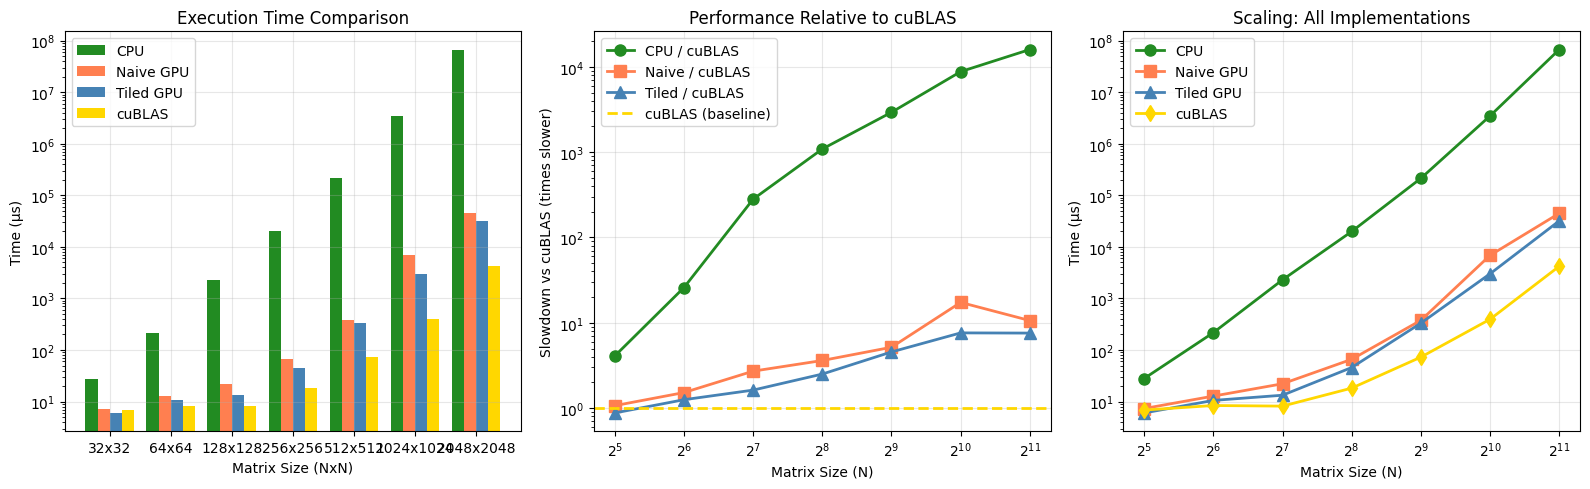

Graph saved to matmul_benchmark.png


In [14]:
# Filter out None values for plotting
valid_idx = [i for i in range(len(sizes)) if all([cpu_times[i], naive_times[i], tiled_times[i], cublas_times[i]])]
v_sizes = [sizes[i] for i in valid_idx]
v_cpu = [cpu_times[i] for i in valid_idx]
v_naive = [naive_times[i] for i in valid_idx]
v_tiled = [tiled_times[i] for i in valid_idx]
v_cublas = [cublas_times[i] for i in valid_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: All execution times (log scale bar chart)
ax1 = axes[0]
x = range(len(v_sizes))
width = 0.2
ax1.bar([i - 1.5*width for i in x], v_cpu, width, label='CPU', color='forestgreen')
ax1.bar([i - 0.5*width for i in x], v_naive, width, label='Naive GPU', color='coral')
ax1.bar([i + 0.5*width for i in x], v_tiled, width, label='Tiled GPU', color='steelblue')
ax1.bar([i + 1.5*width for i in x], v_cublas, width, label='cuBLAS', color='gold')
ax1.set_xlabel('Matrix Size (NxN)')
ax1.set_ylabel('Time (μs)')
ax1.set_title('Execution Time Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{s}x{s}' for s in v_sizes])
ax1.set_yscale('log')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Speedup relative to cuBLAS (how many x slower)
ax2 = axes[1]
naive_vs_cublas = [n/c for n, c in zip(v_naive, v_cublas)]
tiled_vs_cublas = [t/c for t, c in zip(v_tiled, v_cublas)]
cpu_vs_cublas = [cp/c for cp, c in zip(v_cpu, v_cublas)]

ax2.plot(v_sizes, cpu_vs_cublas, 'o-', label='CPU / cuBLAS', color='forestgreen', linewidth=2, markersize=8)
ax2.plot(v_sizes, naive_vs_cublas, 's-', label='Naive / cuBLAS', color='coral', linewidth=2, markersize=8)
ax2.plot(v_sizes, tiled_vs_cublas, '^-', label='Tiled / cuBLAS', color='steelblue', linewidth=2, markersize=8)
ax2.axhline(y=1, color='gold', linestyle='--', linewidth=2, label='cuBLAS (baseline)')
ax2.set_xlabel('Matrix Size (N)')
ax2.set_ylabel('Slowdown vs cuBLAS (times slower)')
ax2.set_title('Performance Relative to cuBLAS')
ax2.set_xscale('log', base=2)
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Scaling comparison (line plot)
ax3 = axes[2]
ax3.plot(v_sizes, v_cpu, 'o-', label='CPU', color='forestgreen', linewidth=2, markersize=8)
ax3.plot(v_sizes, v_naive, 's-', label='Naive GPU', color='coral', linewidth=2, markersize=8)
ax3.plot(v_sizes, v_tiled, '^-', label='Tiled GPU', color='steelblue', linewidth=2, markersize=8)
ax3.plot(v_sizes, v_cublas, 'd-', label='cuBLAS', color='gold', linewidth=2, markersize=8)
ax3.set_xlabel('Matrix Size (N)')
ax3.set_ylabel('Time (μs)')
ax3.set_title('Scaling: All Implementations')
ax3.set_xscale('log', base=2)
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matmul_benchmark.png', dpi=150)
plt.show()

print("Graph saved to matmul_benchmark.png")

## GFLOPS Analysis
Raw time hides scaling differences — GFLOPS (2·N³ / time) normalizes for matrix size and shows how efficiently each implementation uses compute.


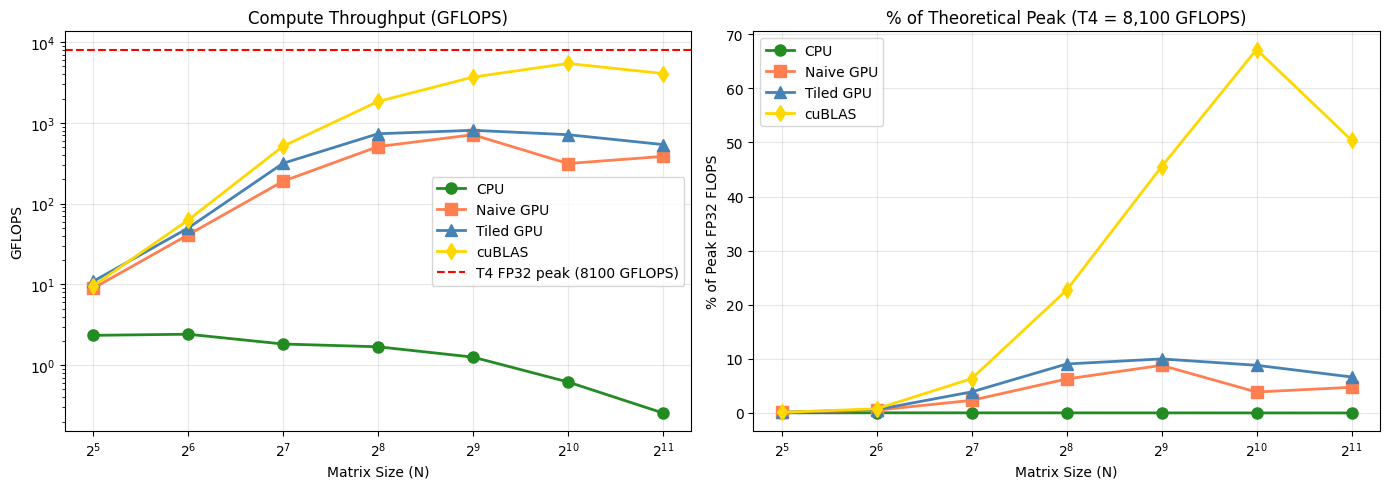


Size       CPU GFLOPS     Naive GFLOPS    Tiled GFLOPS    cuBLAS GFLOPS   Tiled % peak  
-------------------------------------------------------------------------------------
32x32      2.34           8.94            10.89           9.57            0.13          %
64x64      2.42           41.06           49.80           62.53           0.61          %
128x128     1.83           189.42          315.84          514.01          3.90          %
256x256     1.69           508.52          733.27          1839.61         9.05          %
512x512     1.26           713.26          809.25          3688.92         9.99          %
1024x1024    0.62           313.78          714.21          5442.32         8.82          %
2048x2048    0.26           384.35          538.87          4084.42         6.65          %


In [15]:
def to_gflops(N, time_us):
    """GFLOPS = 2*N^3 multiply-adds / time in seconds"""
    if time_us is None or time_us <= 0:
        return None
    return (2 * N**3) / (time_us * 1e-6) / 1e9

v_gflops_cpu    = [to_gflops(N, t) for N, t in zip(v_sizes, v_cpu)]
v_gflops_naive  = [to_gflops(N, t) for N, t in zip(v_sizes, v_naive)]
v_gflops_tiled  = [to_gflops(N, t) for N, t in zip(v_sizes, v_tiled)]
v_gflops_cublas = [to_gflops(N, t) for N, t in zip(v_sizes, v_cublas)]

# Theoretical peak: T4 = ~8.1 TFLOPS FP32, A100 = ~19.5 TFLOPS FP32
# ncu or nvidia-smi can give exact value; use T4 as a Colab default
T4_PEAK_GFLOPS = 8_100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: GFLOPS per implementation
ax = axes[0]
ax.plot(v_sizes, v_gflops_cpu,    'o-', label='CPU',       color='forestgreen', linewidth=2, markersize=8)
ax.plot(v_sizes, v_gflops_naive,  's-', label='Naive GPU',  color='coral',       linewidth=2, markersize=8)
ax.plot(v_sizes, v_gflops_tiled,  '^-', label='Tiled GPU',  color='steelblue',   linewidth=2, markersize=8)
ax.plot(v_sizes, v_gflops_cublas, 'd-', label='cuBLAS',     color='gold',        linewidth=2, markersize=8)
ax.axhline(y=T4_PEAK_GFLOPS, color='red', linestyle='--', linewidth=1.5, label=f'T4 FP32 peak ({T4_PEAK_GFLOPS} GFLOPS)')
ax.set_xlabel('Matrix Size (N)')
ax.set_ylabel('GFLOPS')
ax.set_title('Compute Throughput (GFLOPS)')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: % of peak FLOPS achieved (roofline-lite)
ax2 = axes[1]
def pct_peak(gflops_list):
    return [g / T4_PEAK_GFLOPS * 100 if g else None for g in gflops_list]

ax2.plot(v_sizes, pct_peak(v_gflops_cpu),    'o-', label='CPU',       color='forestgreen', linewidth=2, markersize=8)
ax2.plot(v_sizes, pct_peak(v_gflops_naive),  's-', label='Naive GPU',  color='coral',       linewidth=2, markersize=8)
ax2.plot(v_sizes, pct_peak(v_gflops_tiled),  '^-', label='Tiled GPU',  color='steelblue',   linewidth=2, markersize=8)
ax2.plot(v_sizes, pct_peak(v_gflops_cublas), 'd-', label='cuBLAS',     color='gold',        linewidth=2, markersize=8)
ax2.set_xlabel('Matrix Size (N)')
ax2.set_ylabel('% of Peak FP32 FLOPS')
ax2.set_title('% of Theoretical Peak (T4 = 8,100 GFLOPS)')
ax2.set_xscale('log', base=2)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gflops_analysis.png', dpi=150)
plt.show()

# Print summary table
print(f"\n{'Size':<10} {'CPU GFLOPS':<14} {'Naive GFLOPS':<15} {'Tiled GFLOPS':<15} {'cuBLAS GFLOPS':<15} {'Tiled % peak':<14}")
print("-" * 85)
for i, N in enumerate(v_sizes):
    print(f"{N}x{N:<7} {v_gflops_cpu[i]:<14.2f} {v_gflops_naive[i]:<15.2f} {v_gflops_tiled[i]:<15.2f} {v_gflops_cublas[i]:<15.2f} {v_gflops_tiled[i]/T4_PEAK_GFLOPS*100:<14.2f}%")


## Deep Profiling with ncu (Nsight Compute)
`nvprof` is deprecated on Ampere+ GPUs (Colab A100). Use `ncu` instead for accurate memory throughput, occupancy, and stall analysis.


In [25]:
import subprocess

# Find ncu — skip target-specific sub-binaries, pick the top-level one
r = subprocess.run(
    "find /opt/nvidia/nsight-compute /usr/local/cuda* -name ncu "
    "-not -path '*/target/*' -not -path '*/host/*' -type f 2>/dev/null | head -1",
    shell=True, capture_output=True, text=True
)
NCU_PATH = r.stdout.strip() or "ncu"
print(f"ncu path: {NCU_PATH}")

# Unlock GPU perf counters (Colab T4 restricts these to root by default)
unlock = subprocess.run(
    "sudo sh -c 'echo 0 > /proc/driver/nvidia/params/NVreg_RestrictProfilingToAdminUsers'",
    shell=True, capture_output=True, text=True
)
print("Permissions unlocked." if unlock.returncode == 0 else f"Unlock failed: {unlock.stderr[:100]}")

# Verify: ncu should respond with version
v = subprocess.run(f"{NCU_PATH} --version 2>&1 | head -2", shell=True, capture_output=True, text=True)
print(v.stdout.strip())


ncu path: /opt/nvidia/nsight-compute/2025.1.1/ncu
Unlock failed: sh: 1: cannot create /proc/driver/nvidia/params/NVreg_RestrictProfilingToAdminUsers: Directory nonex
NVIDIA (R) Nsight Compute Command Line Profiler
Copyright (c) 2018-2025 NVIDIA Corporation


In [28]:
import subprocess
import csv
import io

# NOTE: On Colab, the /proc path for unlocking counters may not exist.
# If ncu runs and returns metrics, you're fine without that step.

def ncu_profile(executable, N, kernel_hint=None):
    cmd = (
        f"{NCU_PATH} --set basic --section Occupancy "
        f"--csv --kernel-name-base demangled "
        f"--target-processes application-only "
        f"./{executable} {N} 2>&1"
    )
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    output = result.stdout + result.stderr

    metrics = {}
    col = None
    reader = csv.reader(io.StringIO(output))

    for row in reader:
        if not row:
            continue
        row_clean = [c.strip().strip('"') for c in row]
        first = row_clean[0] if row_clean else ""

        if first.startswith("==") or first.startswith("WARN") or first.startswith("ERROR"):
            continue

        if col is None and ("Metric Name" in row_clean and "Metric Value" in row_clean):
            col = {name: idx for idx, name in enumerate(row_clean)}
            continue

        if col is None:
            continue

        k_col = col.get("Kernel Name", col.get("KernelName"))
        n_col = col.get("Metric Name", col.get("MetricName"))
        v_col = col.get("Metric Value", col.get("MetricValue"))
        u_col = col.get("Metric Unit", col.get("MetricUnit", col.get("Unit")))

        if k_col is None or n_col is None or v_col is None:
            continue
        max_col = max([c for c in [k_col, n_col, v_col, u_col] if c is not None])
        if max_col >= len(row_clean):
            continue

        kernel_name = row_clean[k_col].lower()
        if kernel_hint and kernel_hint.lower() not in kernel_name:
            continue

        metric_name = row_clean[n_col]
        metric_value = row_clean[v_col]
        metric_unit = row_clean[u_col] if u_col is not None else ""

        if metric_name:
            metrics[metric_name] = f"{metric_value} {metric_unit}".strip()

    return metrics, output

def pick_metric(metrics, aliases):
    """Return first matching metric value by exact or case-insensitive alias match."""
    for a in aliases:
        if a in metrics:
            return metrics[a]
    lower_map = {k.lower(): v for k, v in metrics.items()}
    for a in aliases:
        if a.lower() in lower_map:
            return lower_map[a.lower()]
    return "N/A"

# Use names as reported by your ncu build (from debug output)
KEY_METRICS = [
    (["Compute (SM) Throughput", "SM Throughput"], "SM Throughput"),
    (["DRAM Throughput"], "DRAM Throughput"),
    (["Memory Throughput"], "Memory Throughput"),
    (["L1/TEX Cache Throughput", "L1/TEX Throughput"], "L1/TEX Throughput"),
    (["L2 Cache Throughput", "L2 Throughput"], "L2 Throughput"),
    (["Achieved Occupancy", "SM Active Cycles"], "Occupancy / SM Activity"),
    (["Registers Per Thread"], "Registers/Thread"),
    (["Static Shared Memory Per Block", "Dynamic Shared Memory Per Block"], "Shared Mem per Block"),
]

N_profile = 512
print(f"Using ncu: {NCU_PATH}")
print(f"Profiling N={N_profile} for naive/tiled/cuBLAS...\n")

naive_m, naive_raw = ncu_profile("matmul", N_profile, kernel_hint="matmul")
tiled_m, tiled_raw = ncu_profile("matmul-tiled", N_profile, kernel_hint="matmul")
cublas_m, cublas_raw = ncu_profile("matmul-cublas", N_profile, kernel_hint="gemm")

col_w = 24
hdr = f"{'Metric':<30} {'Naive GPU':>{col_w}} {'Tiled GPU':>{col_w}} {'cuBLAS':>{col_w}}"
print(hdr)
print("-" * len(hdr))
for aliases, label in KEY_METRICS:
    n = pick_metric(naive_m, aliases)
    t = pick_metric(tiled_m, aliases)
    c = pick_metric(cublas_m, aliases)
    print(f"{label:<30} {n:>{col_w}} {t:>{col_w}} {c:>{col_w}}")

if not naive_m:
    print("\n[DEBUG] No metrics parsed from naive run. First ~2000 chars:")
    print(naive_raw[:2000])
else:
    print("\n[DEBUG] Parsed metric names (first 20 from naive):")
    for i, k in enumerate(list(naive_m.keys())[:20]):
        print(f"  {i+1:02d}. {k}")


Using ncu: /opt/nvidia/nsight-compute/2025.1.1/ncu
Profiling N=512 for naive/tiled/cuBLAS...

Metric                                        Naive GPU                Tiled GPU                   cuBLAS
---------------------------------------------------------------------------------------------------------
SM Throughput                                   80.67 %                  69.58 %                  67.71 %
DRAM Throughput                                  1.47 %                   1.57 %                   8.76 %
Memory Throughput                               80.67 %                  69.58 %                  31.23 %
L1/TEX Throughput                               88.47 %                  82.46 %                  56.10 %
L2 Throughput                                    4.48 %                   5.59 %                  11.90 %
Occupancy / SM Activity                         98.40 %                 100.03 %                  12.50 %
Registers/Thread                     32 register/thread   